In [225]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression

sns.set_style()

In [226]:
deg_capacity = pd.read_csv('Project_3_Data/RE__Data_for_Degradation/Degradation_45DegC_1C.csv')
deg_resistance = pd.read_csv('Project_3_Data/RE__Data_for_Degradation/Degradation_45DegC_1C_resistance.csv')

cal_capacity = pd.read_excel("Project_3_data/RE__Data_for_Degradation/Calendar_ageing_60degC_SOC_100.xlsx")
cal_resistance = pd.read_excel("Project_3_data/RE__Data_for_Degradation/Calendar_ageing_60degC_SOC_100_resistance_increase.xlsx")

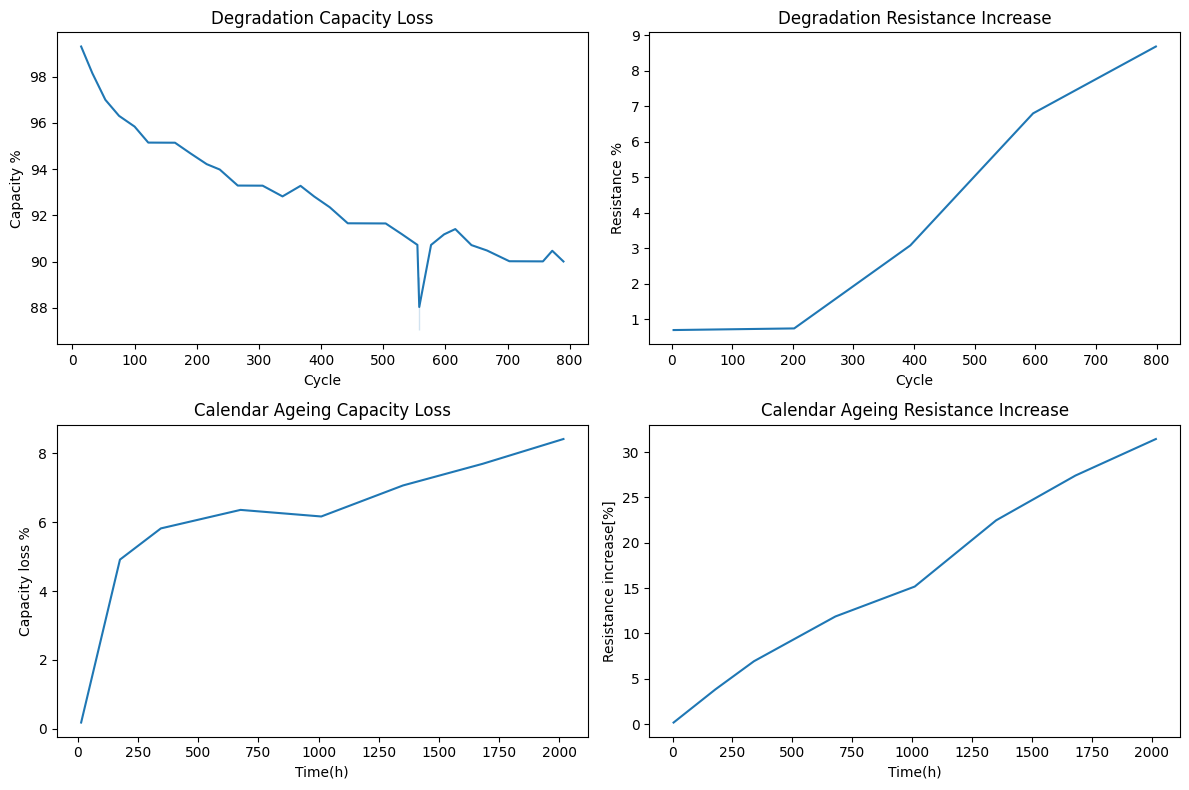

In [227]:
fig, axs = plt.subplots(2,2, figsize=(12,8))
sns.lineplot(data=deg_capacity, x='Cycle', y='Capacity %', ax=axs[0,0])
sns.lineplot(data=deg_resistance, x='Cycle', y='Resistance %', ax=axs[0,1])
sns.lineplot(data=cal_resistance, x='Time(h)', y='Resistance increase[%]', ax=axs[1,1])
sns.lineplot(data=cal_capacity, x='Time(h)', y='Capacity loss %', ax=axs[1,0])

axs[0,0].set_title('Degradation Capacity Loss')
axs[0,1].set_title('Degradation Resistance Increase')
axs[1,0].set_title('Calendar Ageing Capacity Loss')
axs[1,1].set_title('Calendar Ageing Resistance Increase')
plt.tight_layout()
plt.show() 

In [228]:
NOM_CAPACITY = 2.496 #Ah
deg_capacity['Capacity loss'] = 100 - deg_capacity['Capacity %']
deg_capacity['Capacity Throughput (Ah)'] = (deg_capacity['Cycle'] * NOM_CAPACITY * 2)

$$ ln(s_{loss cycle}) = ln(a_c) - \frac{E_{ac}}{RT} + z_a ln(Ah) $$
regress $ ln(s_{loss cycle}) $ against $ ln{Ah} $

let $ K = ln(a_c) - \frac{E_{ac}}{RT} $

In [229]:
# linear regression in log space
ln_s = np.log(deg_capacity['Capacity loss'])
ln_Ah = np.log(deg_capacity['Capacity Throughput (Ah)'])
# ln_Ah = np.array([ln_Ah, np.ones_like(ln_Ah)]).T
# beta = np.linalg.solve(ln_Ah.T @ ln_Ah, ln_Ah.T @ ln_s)

# K = beta[0]
# za = beta[1]
model = LinearRegression().fit(ln_Ah.values.reshape(-1,1), ln_s)
K = model.intercept_
za = model.coef_[0]
print(f"K: {K}, za: {za}")


K: -2.2300991349059807, za: 0.5630048789722595


taking $E_{AC} = 22406 J mol^{-1} $ from Cordoba-Arenas et. al

In [230]:
E_ac = 22406 # J mol^-1
R = 8.314 #J mol^-1 K^-1
T = 45 + 273.15 #K
a_c = np.exp(K + E_ac / (R * T))  
a_c

np.float64(513.1976207062082)

$$ R_{inc cycling} = a_R \times e^{- \frac{E_{AR}}{RT}} \times Ah  $$
let $K_{res} = a_R \times e^{- \frac{E_{AR}}{RT}}$ 



In [231]:
deg_resistance['Capacity Throughput (Ah)'] = (deg_resistance['Cycle'] * NOM_CAPACITY * 2)
thrpt = deg_resistance['Capacity Throughput (Ah)']
res_increase = deg_resistance['Resistance %']
model_res = LinearRegression(fit_intercept=False).fit(thrpt.values.reshape(-1,1), res_increase.values.reshape(-1,1))
K_res = model_res.coef_[0][0]
print(f"K_res: {K_res}")


K_res: 0.0020808729889648285


taking $ E_{AR} = 51800 J mol^{-1} $ from Cordoba-Arenas et. al

In [232]:
E_ar = 51800 # J mol^-1
T = 45 + 273.15 #K
# a_r = np.exp(K_res + E_ar / (R * T))
a_r = K_res / np.exp(-E_ar / (R * T))
a_r

np.float64(665583.5720175531)

$$ ln(S_{loss calendar}) = ln(b_c) - \frac{E_{AC}}{RT} + z_b ln(time)) $$
let $K_{cal cap} = ln(b_c) - \frac{E_{AC}}{RT}$


In [233]:
ln_s_cal_full = np.log(cal_capacity['Capacity loss %'])
ln_time_cal_full = np.log(cal_capacity['Time(h)'])
model_cal_old = LinearRegression().fit(ln_time_cal_full.values.reshape(-1,1), ln_s_cal_full)
K_cal_cap_full = model_cal_old.intercept_
zb_full = model_cal_old.coef_[0]
print(f"K_cal_cap: {K_cal_cap_full}, zb: {zb_full}")

K_cal_cap: -3.0055737867487027, zb: 0.7186542569479994


In [234]:
ln_s_cal = np.log(cal_capacity['Capacity loss %'][1:])
ln_time_cal = np.log(cal_capacity['Time(h)'][1:])
model_cal = LinearRegression().fit(ln_time_cal.values.reshape(-1,1), ln_s_cal)
K_cal_cap = model_cal.intercept_
zb = model_cal.coef_[0]
print(f"K_cal_cap: {K_cal_cap}, zb: {zb}")

K_cal_cap: 0.594202125184873, zb: 0.1924850191857364


In [235]:
T = 60 + 273.15 #K
b_c = np.exp(K_cal_cap + E_ac / (R * T))
b_c

b_c_full = np.exp(K_cal_cap_full + E_ac / (R * T))
b_c_full

np.float64(161.38492856810674)

$$ R_{inc calendar} = b_R \times e^{- \frac{E_{AR}}{RT}} \times time $$
let $K_{res cal} = b_R \times e^{- \frac{E_{AR}}{RT}}$ 

In [236]:
time = cal_resistance['Time(h)']
R_cal = cal_resistance['Resistance increase[%]']

model_cal_res = LinearRegression(fit_intercept=False).fit(time.values.reshape(-1,1), R_cal.values.reshape(-1,1))
K_res_cal = model_cal_res.coef_[0][0]
print(f"K_res_cal: {K_res_cal}")

T = 60 + 273.15 #K
b_r = K_res_cal / np.exp(-E_ar / (R * T))
b_r

K_res_cal: 0.01606994570700646


np.float64(2128324.043767713)

In [237]:
def capacity_loss_cycle_pred(throughput, temp, a_c=a_c, za=za):
    E_ac = 22406 # J mol^-1
    R = 8.314 #J mol^-1 K^-1
    T = temp + 273.15 #K
    return a_c * np.exp(-E_ac / (R * T)) * throughput**za

def resistance_increase_cycle_pred(throughput, temp, a_r=a_r):
    E_ar = 51800 # J mol^-1
    R = 8.314 #J mol^-1 K^-1
    T = temp + 273.15 #K
    return a_r * np.exp(-E_ar / (R * T)) * throughput

def capacity_loss_cal_pred(time, temp, b_c=b_c, zb=zb):
    E_ac = 22406 # J mol^-1
    R = 8.314 #J mol^-1 K^-1
    T = temp + 273.15 #K
    return b_c * np.exp(-E_ac / (R * T)) * time**zb

def resistance_increase_cal_pred(time, temp, b_r=b_r):
    E_ar = 51800 # J mol^-1
    R = 8.314 #J mol^-1 K^-1
    T = temp + 273.15 #K
    return b_r * np.exp(-E_ar / (R * T)) * time


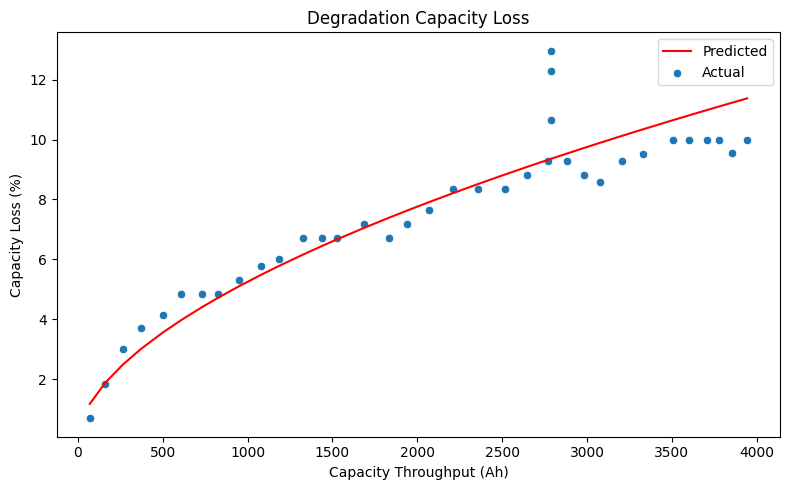

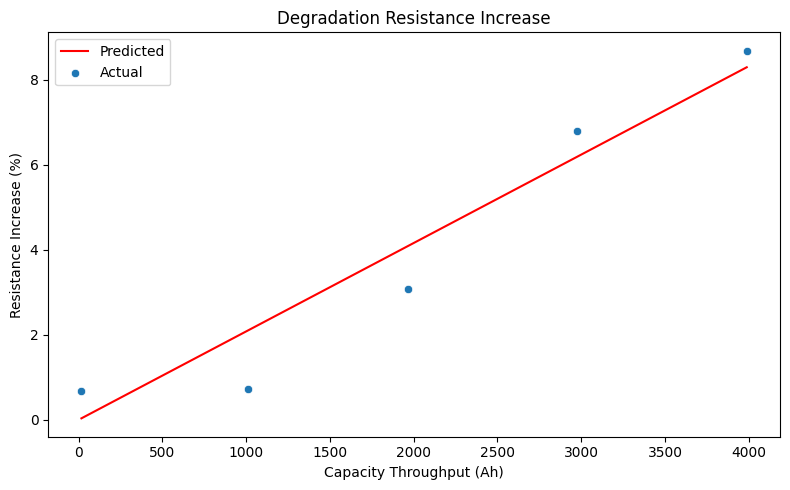

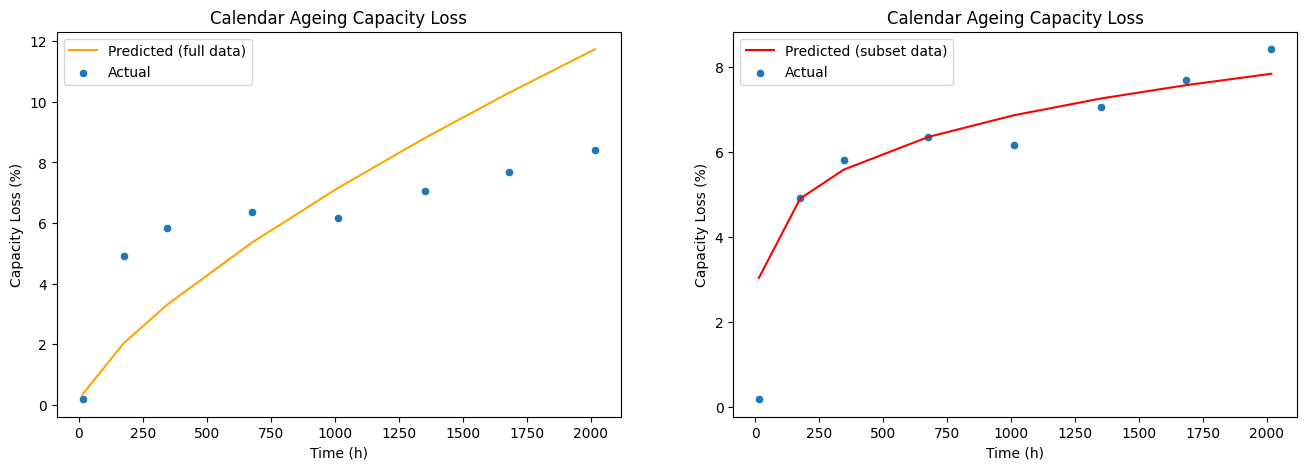

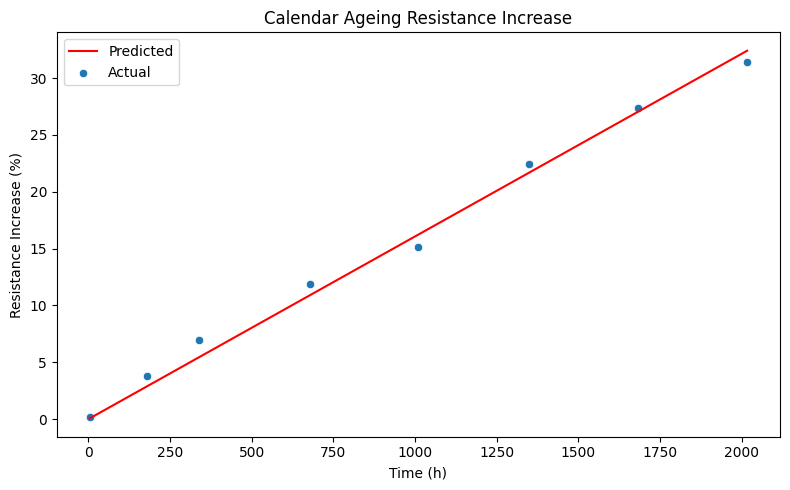

In [238]:
cap_loss_45 = capacity_loss_cycle_pred(deg_capacity['Capacity Throughput (Ah)'], 45)
res_increase_45 = resistance_increase_cycle_pred(deg_resistance['Capacity Throughput (Ah)'], 45)
cap_loss_60 = capacity_loss_cal_pred(cal_capacity['Time(h)'], 60)
res_increase_60 = resistance_increase_cal_pred(cal_resistance['Time(h)'], 60)

cap_loss_60_full = capacity_loss_cal_pred(cal_capacity['Time(h)'], 60, b_c_full, zb_full)

# plot each result in its own figure
plt.figure(figsize=(8, 5))
sns.lineplot(x=deg_capacity['Capacity Throughput (Ah)'], y=cap_loss_45, label='Predicted', color='red')
sns.scatterplot(data=deg_capacity, x='Capacity Throughput (Ah)', y='Capacity loss', label='Actual')
plt.title('Degradation Capacity Loss')
plt.xlabel('Capacity Throughput (Ah)')
plt.ylabel('Capacity Loss (%)')
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 5))
sns.lineplot(x=deg_resistance['Capacity Throughput (Ah)'], y=res_increase_45, label='Predicted', color='red')
sns.scatterplot(data=deg_resistance, x='Capacity Throughput (Ah)', y='Resistance %', label='Actual')
plt.title('Degradation Resistance Increase')
plt.xlabel('Capacity Throughput (Ah)')
plt.ylabel('Resistance Increase (%)')
plt.tight_layout()
plt.show()

# plt.figure(figsize=(8, 5))
# sns.lineplot(x=cal_capacity['Time(h)'], y=cap_loss_60_full, label='Predicted (full data)', color='blue')
# sns.lineplot(x=cal_capacity['Time(h)'], y=cap_loss_60, label='Predicted (subset data)', color='red')
# sns.scatterplot(data=cal_capacity, x='Time(h)', y='Capacity loss %', label='Actual')
# plt.title('Calendar Ageing Capacity Loss')
# plt.xlabel('Time (h)')
# plt.ylabel('Capacity Loss (%)')
# plt.tight_layout()
# plt.show()

# plt.figure(figsize=(8, 5))
# sns.lineplot(x=cal_capacity['Time(h)'], y=cap_loss_60, label='Predicted', color='red')
# sns.scatterplot(data=cal_capacity, x='Time(h)', y='Capacity loss %', label='Actual')
# plt.title('Calendar Ageing Capacity Loss')
# plt.xlabel('Time (h)')
# plt.ylabel('Capacity Loss (%)')
# plt.tight_layout()
# plt.show()

fig, axs = plt.subplots(1, 2, figsize=(16, 5))
sns.lineplot(x=cal_capacity['Time(h)'], y=cap_loss_60_full, label='Predicted (full data)', color='orange', ax=axs[0])
sns.lineplot(x=cal_capacity['Time(h)'], y=cap_loss_60, label='Predicted (subset data)', color='red', ax=axs[1])
sns.scatterplot(data=cal_capacity, x='Time(h)', y='Capacity loss %', label='Actual', ax=axs[0])
sns.scatterplot(data=cal_capacity, x='Time(h)', y='Capacity loss %', label='Actual', ax=axs[1])
axs[0].set_title('Calendar Ageing Capacity Loss')
axs[0].set_xlabel('Time (h)')
axs[0].set_ylabel('Capacity Loss (%)')
axs[1].set_title('Calendar Ageing Capacity Loss')
axs[1].set_xlabel('Time (h)')
axs[1].set_ylabel('Capacity Loss (%)')
plt.show()

plt.figure(figsize=(8, 5))
sns.lineplot(x=cal_resistance['Time(h)'], y=res_increase_60, label='Predicted', color='red')
sns.scatterplot(data=cal_resistance, x='Time(h)', y='Resistance increase[%]', label='Actual')
plt.title('Calendar Ageing Resistance Increase')
plt.xlabel('Time (h)')
plt.ylabel('Resistance Increase (%)')
plt.tight_layout()
plt.show()

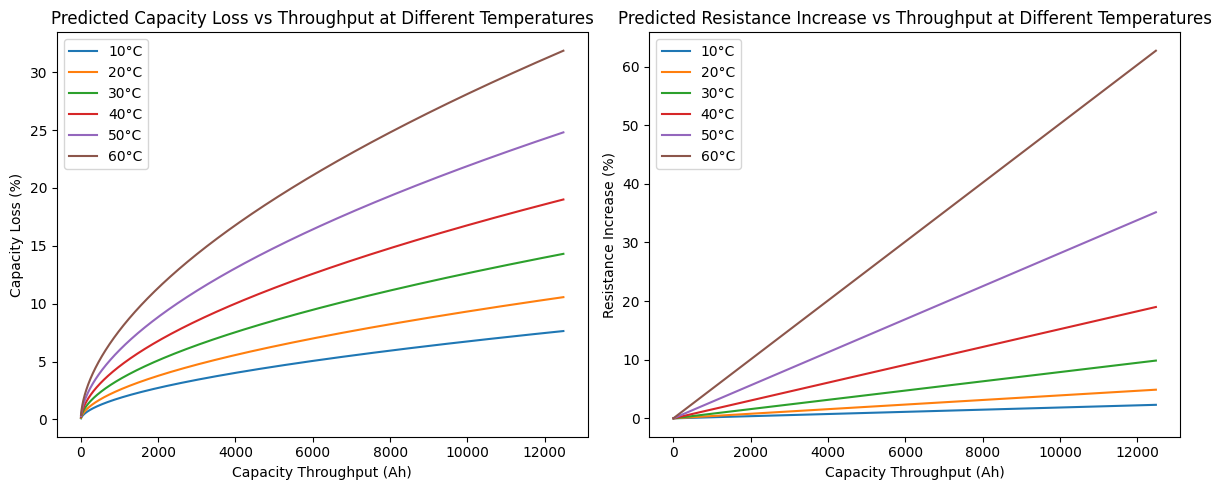

In [239]:
temp_range = np.arange(10,61,10)
CYCLE_HOURS = 5000
num_cycles = CYCLE_HOURS / 2  # assuming 1C charge / discharge, so 2 hours per cycle
cycle_range = np.arange(1, num_cycles+1)
throughput_range = cycle_range * NOM_CAPACITY * 2

pred_capacity_loss = []
pred_res_increase = []

for temp in temp_range:
    pred_capacity_loss.append(capacity_loss_cycle_pred(throughput_range, temp))
    pred_res_increase.append(resistance_increase_cycle_pred(throughput_range, temp))

fig, axs = plt.subplots(1,2, figsize=(12,5))
for i, temp in enumerate(temp_range):
    sns.lineplot(x=throughput_range, y=pred_capacity_loss[i], ax=axs[0], label=f'{temp}°C')
    sns.lineplot(x=throughput_range, y=pred_res_increase[i], ax=axs[1], label=f'{temp}°C')
axs[0].set_title('Predicted Capacity Loss vs Throughput at Different Temperatures')
axs[0].set_xlabel('Capacity Throughput (Ah)')
axs[0].set_ylabel('Capacity Loss (%)')  
axs[1].set_title('Predicted Resistance Increase vs Throughput at Different Temperatures')
axs[1].set_xlabel('Capacity Throughput (Ah)')
axs[1].set_ylabel('Resistance Increase (%)')

# # plot lines at 30% capacity loss and 100% resistance increase
# axs[0].axhline(30, color='red', linestyle='--', label='30% Capacity Loss')
# axs[1].axhline(100, color='red', linestyle='--', label='100% Resistance Increase')
# axs[0].legend()
# axs[1].legend()

plt.tight_layout()
plt.show()  



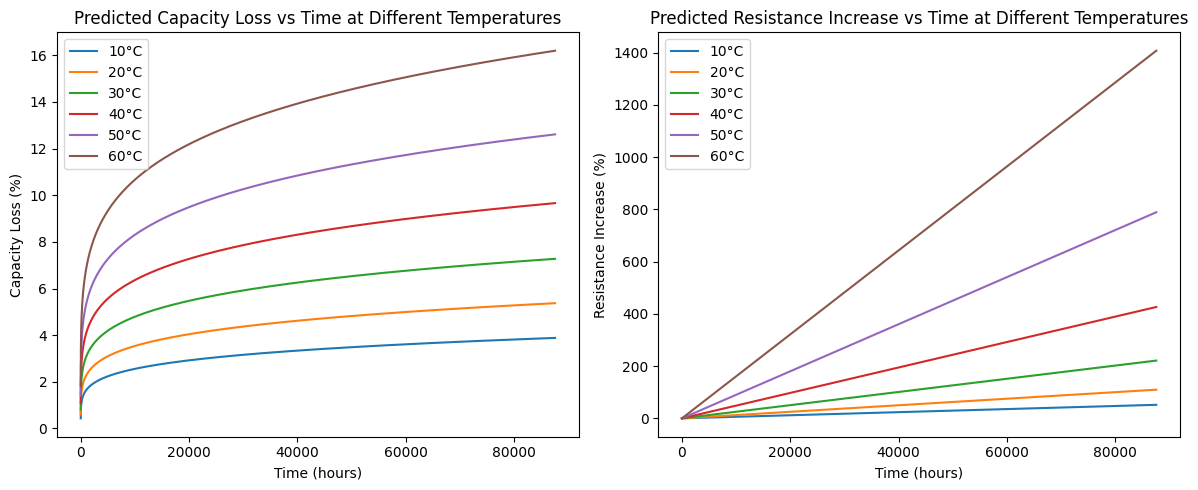

In [240]:
NUM_YEARS = 10
hours_per_year = 365 * 24
total_hours = NUM_YEARS * hours_per_year
hours_range = np.arange(1, total_hours+1)

pred_capacity_loss_cal = []
pred_res_increase_cal = []
for temp in temp_range:
    pred_capacity_loss_cal.append(capacity_loss_cal_pred(hours_range, temp))
    pred_res_increase_cal.append(resistance_increase_cal_pred(hours_range, temp))
fig, axs = plt.subplots(1,2, figsize=(12,5))
for i, temp in enumerate(temp_range):
    sns.lineplot(x=hours_range, y=pred_capacity_loss_cal[i], ax=axs[0], label=f'{temp}°C')
    sns.lineplot(x=hours_range, y=pred_res_increase_cal[i], ax=axs[1], label=f'{temp}°C')
axs[0].set_title('Predicted Capacity Loss vs Time at Different Temperatures')
axs[0].set_xlabel('Time (hours)')
axs[0].set_ylabel('Capacity Loss (%)')
axs[1].set_title('Predicted Resistance Increase vs Time at Different Temperatures')
axs[1].set_xlabel('Time (hours)')
axs[1].set_ylabel('Resistance Increase (%)')

# plot lines at 30% capacity loss and 100% resistance increase
# axs[0].axhline(30, color='red', linestyle='--', label='30% Capacity Loss')
# axs[1].axhline(100, color='red', linestyle='--', label='100% Resistance Increase')
# axs[0].legend()
# axs[1].legend() 

plt.tight_layout()
plt.show()


In [241]:
print("Model parameters:")
print(f"a_c: {a_c}, za: {za}")
print(f"a_r: {a_r}")
print(f"b_c: {b_c}, zb: {zb}")
print(f"b_r: {b_r}")


Model parameters:
a_c: 513.1976207062082, za: 0.5630048789722595
a_r: 665583.5720175531
b_c: 5905.08004516816, zb: 0.1924850191857364
b_r: 2128324.043767713


In [242]:
london_temp = 11.4 #C
sg_temp = 27.7 #C
iceland_temp = 4.7 #C

def get_resistance_increase_time(temp, threshold=100):
    temp += 273.15 # convert to K
    return threshold / (b_r * np.exp(-E_ar / (R * temp)))

def get_capacity_loss_time(temp, threshold=30):
    temp += 273.15 # convert to K
    return (threshold / (b_c * np.exp(-E_ac / (R * temp)))) ** (1/zb)

london_res_increase_time = get_resistance_increase_time(london_temp)
sg_res_increase_time = get_resistance_increase_time(sg_temp)
iceland_res_increase_time = get_resistance_increase_time(iceland_temp)  
london_capacity_loss_time = get_capacity_loss_time(london_temp)
sg_capacity_loss_time = get_capacity_loss_time(sg_temp)
iceland_capacity_loss_time = get_capacity_loss_time(iceland_temp)   

print(f"Time to reach 100% resistance increase:")
print(f"London: {london_res_increase_time/365/24:.2f} years")
print(f"Singapore: {sg_res_increase_time/365/24:.2f} years")
print(f"Iceland: {iceland_res_increase_time/365/24:.2f} years")
print(f"Time to reach 30% capacity loss:")
print(f"London: {london_capacity_loss_time/365/24:.2f} years")
print(f"Singapore: {sg_capacity_loss_time/365/24:.2f} years")
print(f"Iceland: {iceland_capacity_loss_time/365/24:.2f} years")



Time to reach 100% resistance increase:
London: 17.33 years
Singapore: 5.29 years
Iceland: 29.38 years
Time to reach 30% capacity loss:
London: 322172.20 years
Singapore: 22403.83 years
Iceland: 1055293.00 years


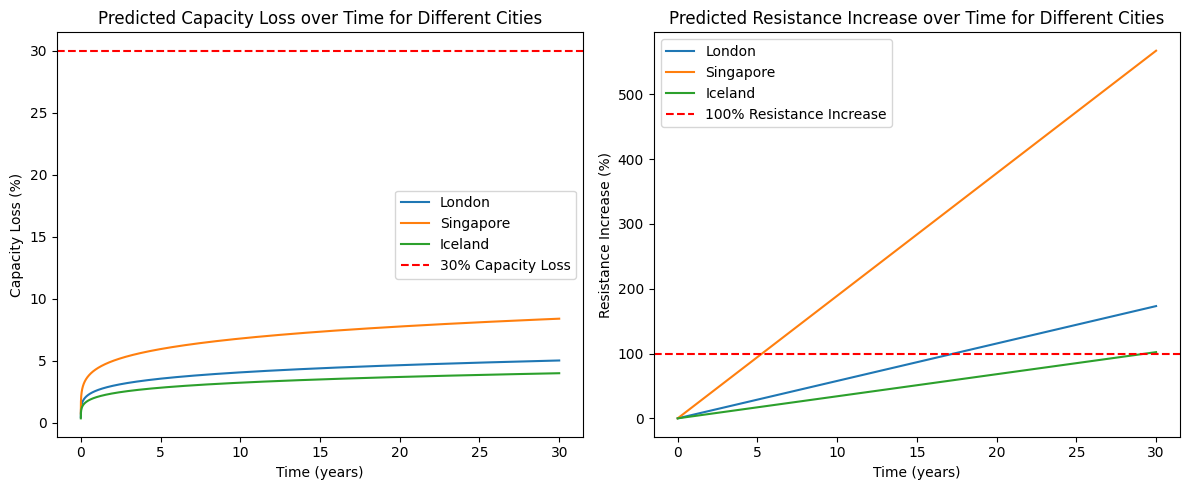

In [243]:
years = 30
cities_time = np.arange(1, years*365*24 + 1) # hours in 30 years, with 1000 hour intervals
london_cap_loss = capacity_loss_cal_pred(cities_time, london_temp)
sg_cap_loss = capacity_loss_cal_pred(cities_time, sg_temp)
iceland_cap_loss = capacity_loss_cal_pred(cities_time, iceland_temp)

london_res_inc = resistance_increase_cal_pred(cities_time, london_temp)
sg_res_inc = resistance_increase_cal_pred(cities_time, sg_temp)
iceland_res_inc = resistance_increase_cal_pred(cities_time, iceland_temp)

plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
sns.lineplot(x=cities_time/365/24, y=london_cap_loss, label='London')
sns.lineplot(x=cities_time/365/24, y=sg_cap_loss, label='Singapore')
sns.lineplot(x=cities_time/365/24, y=iceland_cap_loss, label='Iceland')
plt.axhline(30, color='red', linestyle='--', label='30% Capacity Loss')
plt.title('Predicted Capacity Loss over Time for Different Cities')
plt.xlabel('Time (years)')
plt.ylabel('Capacity Loss (%)')
plt.legend()    
plt.subplot(1,2,2)
sns.lineplot(x=cities_time/365/24, y=london_res_inc, label='London')
sns.lineplot(x=cities_time/365/24, y=sg_res_inc, label='Singapore')
sns.lineplot(x=cities_time/365/24, y=iceland_res_inc, label='Iceland')
plt.axhline(100, color='red', linestyle='--', label='100% Resistance Increase')
plt.title('Predicted Resistance Increase over Time for Different Cities')
plt.xlabel('Time (years)')
plt.ylabel('Resistance Increase (%)')
plt.legend()
plt.tight_layout()
plt.show()


In [245]:
eight_year_temp = E_ar / (np.log(b_r * 8*365*24 / 100)* R) - 273.15
print(f"Temperature at which 100% resistance increase occurs at 8 years: {eight_year_temp:.2f} °C")

Temperature at which 100% resistance increase occurs at 8 years: 21.81 °C
